<a href="https://colab.research.google.com/github/Pillapanda/transformer-from-scratch/blob/main/Multihead_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as  np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

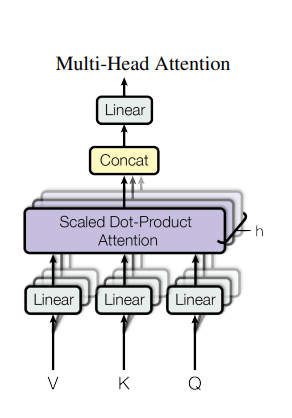

I agree with you. That sounds like a good idea

In [ ]:
sequence_length=10
batch_size=1
input_dim=512
d_model=512
x=torch.randn((batch_size,sequence_length,input_dim))

In [ ]:
x.shape

torch.Size([1, 10, 512])

In [ ]:
qkv_layer=nn.Linear(input_dim,3*d_model)

In [ ]:

qkv_layer    ## we only intialize

Linear(in_features=512, out_features=1536, bias=True)

In [ ]:
qkv=qkv_layer(x)

In [ ]:
qkv.shape

torch.Size([1, 10, 1536])

In [ ]:
d_model

512

In [ ]:
num_heads=8
head_dim=d_model//num_heads

In [ ]:
head_dim

64

In [ ]:
## we do the reshaping of qkv

In [ ]:
x=torch.randn(10,2)

In [ ]:
x

tensor([[-1.0047,  0.0500],
        [-0.8264,  0.8389],
        [ 0.4256,  0.4617],
        [ 1.0754, -0.3891],
        [-1.4822,  0.6785],
        [-0.6131,  1.7526],
        [-0.8433,  0.8084],
        [ 0.8712,  0.9681],
        [-1.9963, -0.4819],
        [-1.1638, -1.1906]])

In [ ]:
x.shape

torch.Size([10, 2])

In [ ]:

x.reshape(5,4)

tensor([[-1.0047,  0.0500, -0.8264,  0.8389],
        [ 0.4256,  0.4617,  1.0754, -0.3891],
        [-1.4822,  0.6785, -0.6131,  1.7526],
        [-0.8433,  0.8084,  0.8712,  0.9681],
        [-1.9963, -0.4819, -1.1638, -1.1906]])

In [ ]:
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim)

print(qkv.shape)

torch.Size([1, 10, 8, 192])


In [ ]:
qkv

tensor([[[[ 1.1894e+00, -3.3287e-01,  6.4626e-01,  ...,  5.5401e-01,
            9.0575e-01,  9.4691e-01],
          [ 5.3464e-01, -9.5865e-01, -3.9140e-01,  ..., -6.8265e-01,
            9.3583e-01,  5.1888e-01],
          [ 1.7661e-01,  3.6504e-01, -3.0837e-01,  ..., -1.7754e-01,
            2.4364e-01,  1.0478e+00],
          ...,
          [-8.6896e-02, -2.0248e-01, -6.5135e-01,  ...,  9.7969e-01,
            3.8206e-01, -2.6972e-01],
          [ 4.1915e-01, -2.5634e-01, -7.7325e-01,  ...,  1.7851e-01,
            6.6117e-01, -2.2866e-01],
          [-7.8008e-01,  2.1924e-01,  4.8940e-01,  ..., -1.1990e-01,
            2.7150e-01,  4.3420e-01]],

         [[-7.2680e-01,  6.4241e-02,  1.9639e-01,  ...,  1.3947e-01,
            4.5097e-01,  4.7872e-01],
          [-2.7339e-01,  1.9532e-01, -1.0766e+00,  ..., -3.3152e-01,
           -1.6699e-01,  1.6688e-01],
          [ 2.9827e-02,  6.5383e-02,  8.3170e-01,  ..., -8.5618e-01,
            1.1053e-01,  7.7519e-01],
          ...,
     

In [ ]:
qkv.shape  ## reshape the size

torch.Size([1, 10, 8, 192])

In [ ]:
##  change the dimsensions

In [ ]:
qkv = qkv.permute(0, 2, 1, 3)
qkv.shape

torch.Size([1, 8, 10, 192])

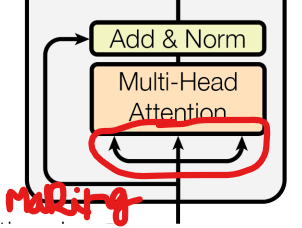

In [ ]:
  # batch=2, seq=10, 3*64
q, k, v = qkv.chunk(3, dim=-1)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([1, 8, 10, 64])
torch.Size([1, 8, 10, 64])
torch.Size([1, 8, 10, 64])


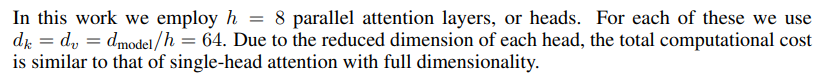

we dive the d_model divide/8 and they divide into the 64 dim into 8 parts

# Self attention with multi-attention

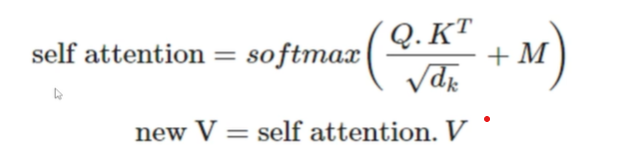

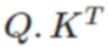

In [ ]:
q.shape

torch.Size([1, 8, 10, 64])

In [ ]:
k.shape

torch.Size([1, 8, 10, 64])

In [ ]:
k.T

tensor([[[[ 3.8361e-01],
          [ 8.4312e-01],
          [ 2.3568e-01],
          ...,
          [-3.8458e-01],
          [-2.5853e-01],
          [-5.5634e-01]],

         [[-3.4956e-01],
          [-6.4429e-01],
          [-3.9905e-01],
          ...,
          [-4.9762e-02],
          [ 6.2263e-02],
          [-1.1750e-01]],

         [[ 3.2775e-01],
          [ 5.1399e-01],
          [-2.2993e-01],
          ...,
          [-4.5739e-01],
          [ 3.6084e-01],
          [-6.5079e-01]],

         ...,

         [[-6.7383e-01],
          [-5.1489e-01],
          [ 5.8945e-01],
          ...,
          [ 3.1975e-01],
          [-3.3261e-02],
          [ 4.5869e-01]],

         [[-1.8682e-01],
          [-4.7340e-01],
          [ 2.0531e-01],
          ...,
          [ 3.1596e-02],
          [-2.2353e-01],
          [ 3.1302e-01]],

         [[-1.0791e+00],
          [-9.2347e-01],
          [-8.6286e-01],
          ...,
          [ 5.2513e-01],
          [-5.2305e-01],
          

In [ ]:
k.transpose(-2,-1)

tensor([[[[ 3.8361e-01, -3.4956e-01,  3.2775e-01,  ..., -6.7383e-01,
           -1.8682e-01, -1.0791e+00],
          [ 5.4597e-01,  1.7126e-01,  9.3019e-01,  ...,  2.5663e-02,
            5.3513e-01, -5.4496e-01],
          [-3.2410e-01,  1.0102e+00, -4.5517e-01,  ..., -1.0377e+00,
            4.5666e-01, -3.3323e-01],
          ...,
          [-5.8314e-01,  8.9914e-02, -3.2365e-01,  ..., -1.1213e+00,
           -7.0957e-01,  4.1136e-01],
          [ 2.1987e-01, -3.0295e-02,  8.1008e-01,  ..., -8.1818e-02,
            7.7681e-02,  7.8657e-01],
          [ 4.9878e-01, -2.6706e-01, -4.1947e-01,  ...,  4.1075e-01,
           -4.7516e-01, -4.4426e-01]],

         [[ 8.4312e-01, -6.4429e-01,  5.1399e-01,  ..., -5.1489e-01,
           -4.7340e-01, -9.2347e-01],
          [ 4.0702e-01, -2.8311e-01, -3.2608e-01,  ...,  5.1171e-01,
           -3.8622e-01, -1.9824e-01],
          [-8.4051e-01,  1.2118e-01, -6.5431e-01,  ..., -4.2424e-01,
            1.3196e-01, -2.2782e-01],
          ...,
     

In [ ]:
torch.matmul(q,k.transpose(-2,-1))

tensor([[[[ 3.0347e+00, -2.7922e+00,  1.3452e+00,  2.7083e+00,  3.4518e-02,
           -3.1859e+00, -3.6544e+00, -5.6968e+00,  6.4058e+00, -5.4666e-03],
          [ 3.8654e+00, -3.2848e+00, -9.3555e-02,  2.8482e+00,  2.0964e-01,
           -2.1602e+00,  1.3491e+00, -4.3116e+00, -5.0191e+00,  4.4014e-01],
          [ 5.3196e-02, -4.5473e-01, -3.8312e+00,  4.2679e+00,  1.9074e+00,
            7.8274e-01, -5.5148e-01,  9.2131e-01, -2.8340e+00,  2.1421e-01],
          [-3.4979e-01,  3.7945e-01, -1.3412e-01, -2.9598e+00, -3.6964e+00,
            1.4387e+00,  3.3630e+00, -8.9705e-01, -3.0086e+00,  1.9172e+00],
          [-1.6728e+00,  8.2740e-01, -4.0714e+00,  3.0868e+00, -6.2066e+00,
            2.9104e+00,  5.2663e+00,  5.1388e+00, -8.7285e-01, -4.6892e+00],
          [-6.2285e+00, -1.6009e+00, -9.7092e-01,  5.6362e-01,  7.0186e-01,
           -7.4588e-01,  4.1449e+00, -2.2063e+00, -9.6987e-01, -6.0369e+00],
          [-2.2897e+00,  2.5953e+00, -1.8304e+00, -1.2018e+00, -8.4712e-01,
      

In [ ]:
qkv.shape

torch.Size([1, 8, 10, 192])

In [ ]:
k.size()

torch.Size([1, 8, 10, 64])

In [ ]:
d_k=k.size()[-1]

In [ ]:
d_k

64

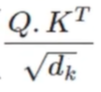

all the multiplication of this matricses of all heads in Q,K and v

In [ ]:
scaled=torch.matmul(q,k.transpose(-2,-1))/math.sqrt(d_k)  ## for two dimesnion

In [ ]:
scaled

tensor([[[[ 3.7934e-01, -3.4902e-01,  1.6815e-01,  3.3854e-01,  4.3148e-03,
           -3.9824e-01, -4.5680e-01, -7.1210e-01,  8.0073e-01, -6.8332e-04],
          [ 4.8317e-01, -4.1060e-01, -1.1694e-02,  3.5602e-01,  2.6205e-02,
           -2.7002e-01,  1.6864e-01, -5.3895e-01, -6.2739e-01,  5.5017e-02],
          [ 6.6495e-03, -5.6841e-02, -4.7890e-01,  5.3348e-01,  2.3842e-01,
            9.7843e-02, -6.8935e-02,  1.1516e-01, -3.5425e-01,  2.6776e-02],
          [-4.3724e-02,  4.7431e-02, -1.6765e-02, -3.6997e-01, -4.6205e-01,
            1.7984e-01,  4.2038e-01, -1.1213e-01, -3.7607e-01,  2.3965e-01],
          [-2.0910e-01,  1.0342e-01, -5.0893e-01,  3.8584e-01, -7.7583e-01,
            3.6380e-01,  6.5829e-01,  6.4235e-01, -1.0911e-01, -5.8615e-01],
          [-7.7856e-01, -2.0012e-01, -1.2137e-01,  7.0452e-02,  8.7733e-02,
           -9.3235e-02,  5.1812e-01, -2.7579e-01, -1.2123e-01, -7.5461e-01],
          [-2.8622e-01,  3.2441e-01, -2.2880e-01, -1.5023e-01, -1.0589e-01,
      

In [ ]:
q.size()

torch.Size([1, 8, 10, 64])

In [ ]:
scaled.shape    #multiplication of all heads

torch.Size([1, 8, 10, 10])

Adding masked

In [ ]:
mask=torch.full(scaled.size(),float('-inf'))

In [ ]:
mask

tensor([[[[-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf]],

         [[-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -in

In [ ]:
mask=torch.triu(mask,diagonal=1 )

In [ ]:
mask

tensor([[[[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

         [[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
          [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf]

In [ ]:
mask[0][0]    ##only seee single head

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
scaled+mask

tensor([[[[ 3.7934e-01,        -inf,        -inf,        -inf,        -inf,
                  -inf,        -inf,        -inf,        -inf,        -inf],
          [ 4.8317e-01, -4.1060e-01,        -inf,        -inf,        -inf,
                  -inf,        -inf,        -inf,        -inf,        -inf],
          [ 6.6495e-03, -5.6841e-02, -4.7890e-01,        -inf,        -inf,
                  -inf,        -inf,        -inf,        -inf,        -inf],
          [-4.3724e-02,  4.7431e-02, -1.6765e-02, -3.6997e-01,        -inf,
                  -inf,        -inf,        -inf,        -inf,        -inf],
          [-2.0910e-01,  1.0342e-01, -5.0893e-01,  3.8584e-01, -7.7583e-01,
                  -inf,        -inf,        -inf,        -inf,        -inf],
          [-7.7856e-01, -2.0012e-01, -1.2137e-01,  7.0452e-02,  8.7733e-02,
           -9.3235e-02,        -inf,        -inf,        -inf,        -inf],
          [-2.8622e-01,  3.2441e-01, -2.2880e-01, -1.5023e-01, -1.0589e-01,
      

In [ ]:
(scaled+mask)[0][0]

tensor([[ 0.3793,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [ 0.4832, -0.4106,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [ 0.0066, -0.0568, -0.4789,    -inf,    -inf,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [-0.0437,  0.0474, -0.0168, -0.3700,    -inf,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [-0.2091,  0.1034, -0.5089,  0.3858, -0.7758,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [-0.7786, -0.2001, -0.1214,  0.0705,  0.0877, -0.0932,    -inf,    -inf,
            -inf,    -inf],
        [-0.2862,  0.3244, -0.2288, -0.1502, -0.1059, -0.0801,  0.5893,    -inf,
            -inf,    -inf],
        [-0.0056,  0.0954, -0.4121,  0.3906, -0.3449, -0.3685, -0.0148,  0.0780,
            -inf,    -inf],
        [ 0.0046, -0.1938, -0.2863,  0.3130, -0.6083,  0.0298,  0.0506, -0.2478,
          0.0306,    -inf],
        [-0.2538,  

In [ ]:
## apply softmax

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

In [ ]:
attention=F.softmax(scaled,dim=-1)  # softmax apply on the last scled dimension value softmax was applied on that

In [ ]:
attention

tensor([[[[0.1356, 0.0654, 0.1098, 0.1302, 0.0932, 0.0623, 0.0588, 0.0455,
           0.2066, 0.0927],
          [0.1646, 0.0673, 0.1004, 0.1450, 0.1042, 0.0775, 0.1202, 0.0592,
           0.0542, 0.1073],
          [0.0965, 0.0906, 0.0594, 0.1634, 0.1217, 0.1057, 0.0895, 0.1076,
           0.0673, 0.0985],
          [0.0969, 0.1061, 0.0995, 0.0699, 0.0638, 0.1211, 0.1541, 0.0905,
           0.0695, 0.1286],
          [0.0726, 0.0992, 0.0538, 0.1316, 0.0412, 0.1287, 0.1728, 0.1701,
           0.0802, 0.0498],
          [0.0508, 0.0906, 0.0981, 0.1188, 0.1209, 0.1009, 0.1859, 0.0840,
           0.0981, 0.0521],
          [0.0726, 0.1338, 0.0769, 0.0832, 0.0870, 0.0893, 0.1743, 0.0588,
           0.0975, 0.1266],
          [0.1056, 0.1169, 0.0704, 0.1570, 0.0753, 0.0735, 0.1047, 0.1149,
           0.0943, 0.0875],
          [0.0952, 0.0781, 0.0712, 0.1296, 0.0516, 0.0977, 0.0997, 0.0740,
           0.0977, 0.2052],
          [0.0703, 0.0964, 0.0614, 0.0745, 0.0641, 0.2938, 0.0948, 0.0949

In [ ]:
attention.shape

torch.Size([1, 8, 10, 10])

In [ ]:
attention[0][0]

tensor([[0.1356, 0.0654, 0.1098, 0.1302, 0.0932, 0.0623, 0.0588, 0.0455, 0.2066,
         0.0927],
        [0.1646, 0.0673, 0.1004, 0.1450, 0.1042, 0.0775, 0.1202, 0.0592, 0.0542,
         0.1073],
        [0.0965, 0.0906, 0.0594, 0.1634, 0.1217, 0.1057, 0.0895, 0.1076, 0.0673,
         0.0985],
        [0.0969, 0.1061, 0.0995, 0.0699, 0.0638, 0.1211, 0.1541, 0.0905, 0.0695,
         0.1286],
        [0.0726, 0.0992, 0.0538, 0.1316, 0.0412, 0.1287, 0.1728, 0.1701, 0.0802,
         0.0498],
        [0.0508, 0.0906, 0.0981, 0.1188, 0.1209, 0.1009, 0.1859, 0.0840, 0.0981,
         0.0521],
        [0.0726, 0.1338, 0.0769, 0.0832, 0.0870, 0.0893, 0.1743, 0.0588, 0.0975,
         0.1266],
        [0.1056, 0.1169, 0.0704, 0.1570, 0.0753, 0.0735, 0.1047, 0.1149, 0.0943,
         0.0875],
        [0.0952, 0.0781, 0.0712, 0.1296, 0.0516, 0.0977, 0.0997, 0.0740, 0.0977,
         0.2052],
        [0.0703, 0.0964, 0.0614, 0.0745, 0.0641, 0.2938, 0.0948, 0.0949, 0.1000,
         0.0499]], grad_fn=<

In [ ]:
values=torch.matmul(attention,v)

In [ ]:
values

tensor([[[[-2.2557e-02, -7.2937e-02,  1.7302e-01,  ..., -2.0267e-01,
            5.7189e-01,  4.7429e-02],
          [ 6.1160e-02, -1.5768e-02,  1.6070e-01,  ..., -7.5904e-02,
            3.7094e-01,  2.3725e-01],
          [ 7.9192e-02,  3.8126e-03,  1.8603e-01,  ..., -1.1037e-01,
            2.9849e-01,  1.2469e-01],
          ...,
          [ 3.6891e-02, -3.5855e-02,  1.6902e-01,  ..., -6.5471e-02,
            3.3099e-01,  9.2146e-02],
          [-1.2032e-02, -1.6389e-02,  2.4953e-01,  ..., -2.1811e-01,
            2.8196e-01,  1.2786e-02],
          [-2.1034e-01,  1.3935e-01,  2.1834e-01,  ..., -1.9274e-01,
            3.0231e-01, -5.7001e-02]],

         [[ 2.2897e-01, -1.1845e-01,  1.2045e-01,  ..., -5.0133e-01,
            3.7106e-01,  2.1121e-01],
          [ 1.9232e-01, -1.8727e-01,  1.7595e-01,  ..., -6.0551e-01,
            2.3562e-01,  1.4100e-01],
          [ 2.3829e-01, -1.9375e-01,  8.1807e-02,  ..., -4.7000e-01,
            2.4025e-01,  1.6988e-01],
          ...,
     